## Análisis bivariable - Análisis exploratorio de datos (EDA)

### Proyecto:
Pacientes con problemas de hígado - India

**Autor:** Mariana Bedoya Arismendy

### Fecha:
2026-08-18

### Descripción:

En este notebook estudiamos las relaciones entre pares de variables. Las preguntas que guían el análisis son:

1. ¿Los pacientes con problemas de hígado presentan valores diferentes en las pruebas clínicas que los pacientes sanos?
2. ¿La proporción de enfermedad es distinta entre hombres y mujeres?
3. ¿Qué tan relacionadas están las variables numéricas entre sí y qué redundancia existe?
4. ¿El género se relaciona con los valores de las pruebas clínicas?

Responder estas preguntas sirve para identificar las variables más prometedoras para el futuro modelo y para anticipar problemas (por ejemplo, variables redundantes). Como en los notebooks anteriores, aquí solo analizamos: no se entrena ningún modelo ni se transforma el dataset.

## 📚 Importar librerías

In [1]:
# librerías base para ciencia de datos
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# configuración para mostrar solo 2 decimales
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

In [3]:
# imprimir versiones de las librerías para reproducibilidad
print("Versión de Python: ", sys.version)
print("Versión de pandas: ", pd.__version__)
print("Versión de seaborn: ", sns.__version__)

Versión de Python:  3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Versión de pandas:  2.3.3
Versión de seaborn:  0.13.2


## 💾 Cargar datos

Cargamos el dataset del proyecto desde el archivo Parquet intermedio, con la misma verificación de existencia de los notebooks anteriores.

In [4]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
DATA_PATH = (
    DATA_DIR / "02_intermediate/Pacientes_porblemas_higado_india_type_fixed.parquet"
)

assert DATA_PATH.exists(), f"No se encuentra el archivo del proyecto: {DATA_PATH}"

df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(f"Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas")

Dataset cargado: 663 filas y 11 columnas


## 📊 Descripción de los datos

Hicimos la descripción completa (tipos, nulos, duplicados, estadísticas por variable) en el notebook 02; aquí solo dejamos constancia de la estructura sobre la que trabajamos:

- 9 variables numéricas: `Age` y las ocho pruebas clínicas.
- 1 variable categórica explicativa: `Gender` (`Male`/`Female`).
- 1 target categórico: `Dataset`, con valores `'1'` (problemas de hígado) y `'2'` (sin problemas) **almacenados como texto**.

Ese último detalle es importante para lo que sigue: para hacer cálculos numéricos con el target creamos una columna auxiliar `target_num` en una **copia** del DataFrame (1 = problemas de hígado, 0 = sin problemas) usando `map`, de modo que los 15 pacientes sin etiqueta quedan como NaN en lugar de contarse en ninguna de las dos clases. Es una variable temporal exclusiva de este notebook; el archivo Parquet original no se modifica.

In [5]:
# copia de trabajo con columna auxiliar del target (no modifica el archivo original)
# el map deja como NaN los 15 pacientes sin etiqueta, para no contaminar ninguna clase
df = df.copy()
df["target_num"] = df["Dataset"].astype(str).map({"1": 1, "2": 0})

df[["Dataset", "target_num"]].sample(5, random_state=42)

,Dataset,target_num
327,2,0.00
579,1,1.00
513,NaN,NaN
362,2,0.00
265,2,0.00


### 📈 Análisis bivariable

#### Target vs variables numéricas

**Pregunta:** ¿los pacientes con problemas de hígado presentan valores diferentes en las pruebas clínicas?

Primero tomamos una vista general con diagramas de cajas de las nueve variables numéricas separadas por clase del target. Esto nos permite detectar de un vistazo en qué variables se aprecia separación entre las clases y en cuáles no.

/tmp/ipykernel_71867/4055705629.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Dataset", y=col, ax=axes[i], palette=["steelblue", "coral"])
/tmp/ipykernel_71867/4055705629.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Dataset", y=col, ax=axes[i], palette=["steelblue", "coral"])
/tmp/ipykernel_71867/4055705629.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Dataset", y=col, ax=axes[i], palette=["steelblue", "coral"])
/tmp/ipykernel_71867/4055705629.py:17: FutureWarning: 

Passing `palette`

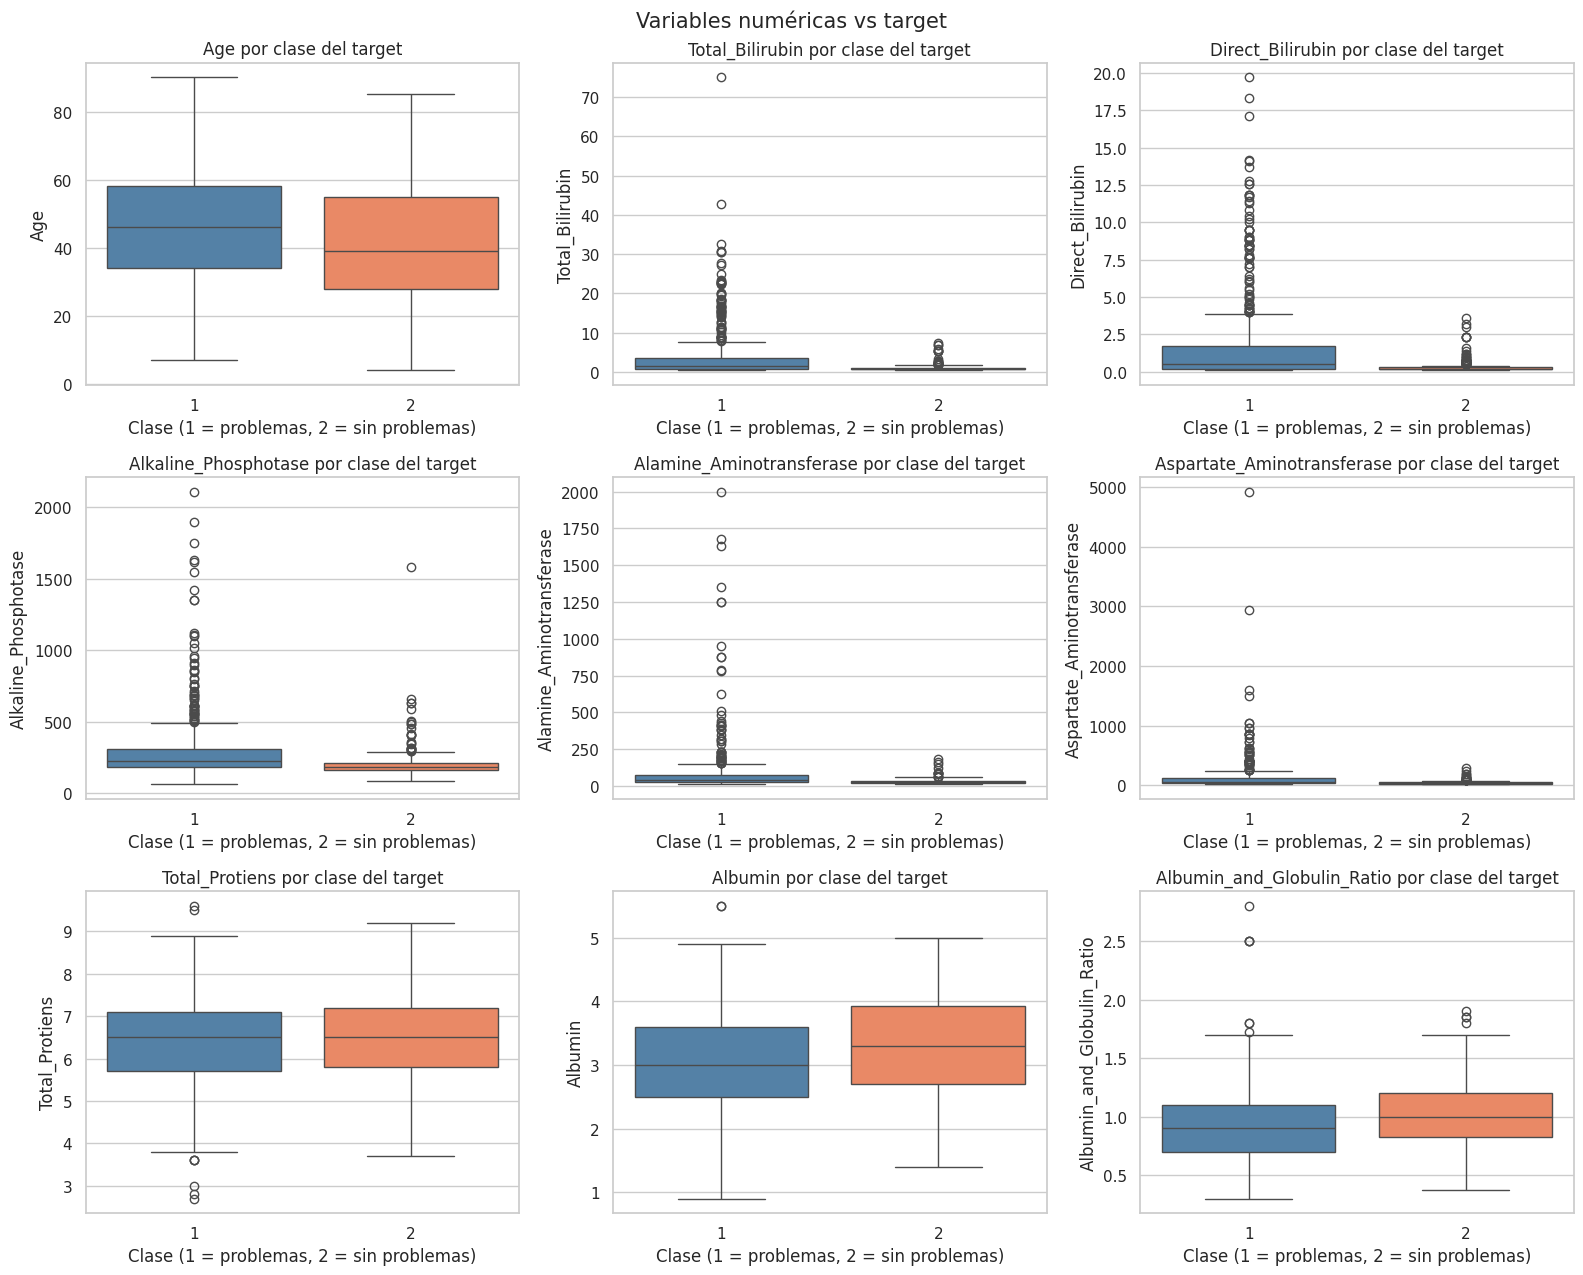

In [6]:
numerical_columns = [
    "Age",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(data=df, x="Dataset", y=col, ax=axes[i], palette=["steelblue", "coral"])
    axes[i].set_title(f"{col} por clase del target")
    axes[i].set_xlabel("Clase (1 = problemas, 2 = sin problemas)")
    axes[i].set_ylabel(col)

plt.suptitle("Variables numéricas vs target", fontsize=15)
plt.tight_layout()
plt.show()

**Qué observamos:** las clases se ven claramente distintas en `Total_Bilirubin`, `Direct_Bilirubin`, `Alamine_Aminotransferase`, `Aspartate_Aminotransferase` y `Alkaline_Phosphotase` (los enfermos tienen valores más altos) y también en `Albumin` y `Albumin_and_Globulin_Ratio` (los enfermos tienen valores más bajos). En `Age` la diferencia es sutil y en `Total_Protiens` prácticamente no se aprecia.

**Advertencia sobre los boxplots:** en las variables con colas largas, la escala de los ejes está dominada por los valores extremos, lo que "aplasta" las cajas. Por eso conviene complementar con las medianas por clase, que son un resumen más robusto.

In [7]:
# medianas por clase del target (estadístico robusto frente a los extremos)
medianas_clase = df.groupby("Dataset", observed=True)[numerical_columns].median().T
medianas_clase.columns = ["1 - problemas", "2 - sin problemas"]
medianas_clase["diferencia (1 - 2)"] = (
    medianas_clase["1 - problemas"] - medianas_clase["2 - sin problemas"]
)
medianas_clase

,1 - problemas,2 - sin problemas,diferencia (1 - 2)
Age,46.00,39.00,7.00
Total_Bilirubin,1.40,0.80,0.60
Direct_Bilirubin,0.50,0.20,0.30
Alkaline_Phosphotase,225.50,188.00,37.50
Alamine_Aminotransferase,40.50,27.00,13.50
Aspartate_Aminotransferase,54.00,29.00,25.00
Total_Protiens,6.50,6.50,0.00
Albumin,3.00,3.30,-0.30
Albumin_and_Globulin_Ratio,0.90,1.00,-0.10


**Resultado:** las medianas confirman el patrón. Los pacientes con problemas de hígado tienen medianas más altas de bilirrubina total (1.4 vs 0.8), bilirrubina directa (0.5 vs 0.2), fosfatasa alcalina (225.5 vs 188), ALT (40.5 vs 27) y AST (54 vs 29); y medianas más bajas de albúmina (3.0 vs 3.3) y ratio A/G (0.9 vs 1.0). La edad también se diferencia (46 vs 39 años) más de lo que el boxplot sugería, mientras que las proteínas totales son idénticas (6.5 en ambas clases).

**Interpretación:** el patrón es el esperable clínicamente: daño hepático eleva enzimas y bilirrubina, y el deterioro de la función baja la albúmina. Que las proteínas totales no se muevan es coherente con que la albúmina baja pero las globulinas suelen subir, compensándose en la suma.

**Implicación:** estas seis variables (bilirrubinas, ALP, transaminasas, albúmina y ratio A/G) son las candidatas naturales para el modelo. A continuación profundizamos en las más relevantes con dos tipos de gráfico complementarios: cajas agrupadas por clase, que resumen la distribución de cada grupo, y curvas de densidad separadas, que muestran dónde se concentra cada uno.

##### Dataset vs Total_Bilirubin

**Pregunta concreta:** ¿la distribución de `Total_Bilirubin` es distinta entre pacientes con y sin problemas de hígado? Comparamos las dos clases con un boxplot agrupado y con las curvas de densidad de cada clase superpuestas, que muestran dónde se concentran los valores de cada grupo.

/tmp/ipykernel_71867/3130957372.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.plot(


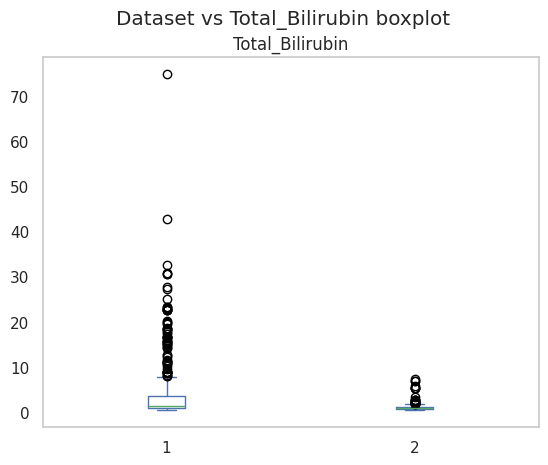

In [8]:
variable = "Total_Bilirubin"

df.plot(
    kind="box",
    column=variable,
    by="Dataset",
    grid=False,
    title=f"Dataset vs Total_Bilirubin boxplot",
);

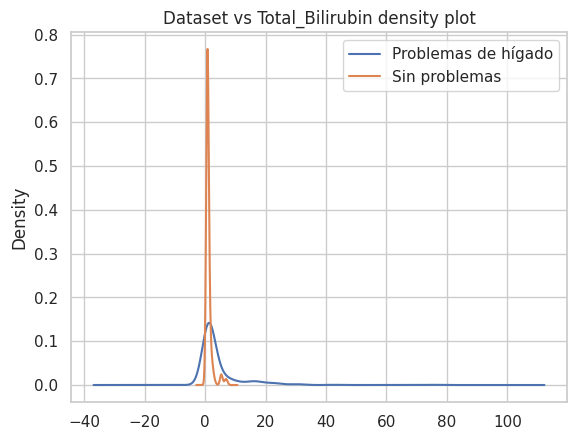

In [9]:
df[df["Dataset"] == "1"][variable].dropna().plot(
    kind="kde",
    label="Problemas de hígado",
    legend=True,
    title=f"Dataset vs Total_Bilirubin density plot",
)
df[df["Dataset"] == "2"][variable].dropna().plot(
    kind="kde",
    label="Sin problemas",
    legend=True,
    xlabel=variable,
    ylabel="Densidad",
);

**Resultado:** la densidad de la clase "sin problemas" está muy concentrada en valores bajos (pico cerca de 0.7), mientras que la clase "problemas de hígado" está más dispersa y desplazada hacia la derecha.

**Interpretación:** la bilirrubina total separa razonablemente bien a los grupos en la zona baja: un valor bajo es más típico de pacientes sanos. Sin embargo, las distribuciones se superponen en un rango amplio, así que la separación no es completa.

**Implicación:** variable prometedora; probablemente entre las más informativas del dataset.

##### Dataset vs Direct_Bilirubin

**Pregunta concreta:** ¿la distribución de `Direct_Bilirubin` es distinta entre pacientes con y sin problemas de hígado? Comparamos las dos clases con un boxplot agrupado y con las curvas de densidad de cada clase superpuestas, que muestran dónde se concentran los valores de cada grupo.

/tmp/ipykernel_71867/3901699656.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.plot(


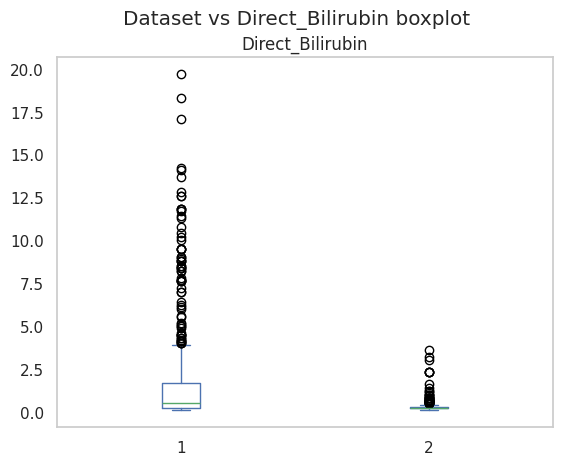

In [10]:
variable = "Direct_Bilirubin"

df.plot(
    kind="box",
    column=variable,
    by="Dataset",
    grid=False,
    title=f"Dataset vs Direct_Bilirubin boxplot",
);

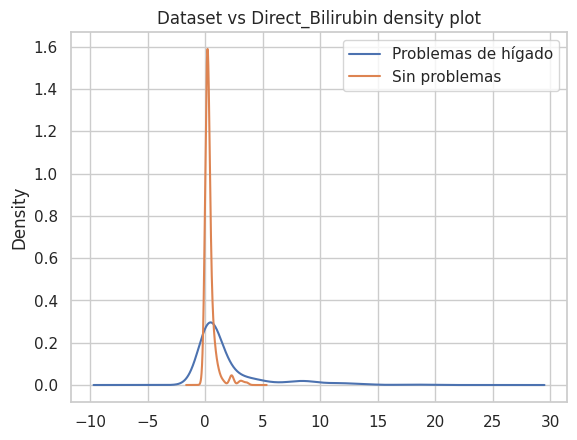

In [11]:
df[df["Dataset"] == "1"][variable].dropna().plot(
    kind="kde",
    label="Problemas de hígado",
    legend=True,
    title=f"Dataset vs Direct_Bilirubin density plot",
)
df[df["Dataset"] == "2"][variable].dropna().plot(
    kind="kde",
    label="Sin problemas",
    legend=True,
    xlabel=variable,
    ylabel="Densidad",
);

**Resultado:** el patrón es prácticamente igual al de la bilirrubina total, con la clase sana concentrada en valores mínimos (mediana 0.2) y la clase enferma más dispersa.

**Interpretación e implicación:** aporta la misma información que la bilirrubina total; la alta correlación entre ambas se cuantifica más abajo en la matriz de correlación.

##### Dataset vs Alamine_Aminotransferase

**Pregunta concreta:** ¿la distribución de `Alamine_Aminotransferase` es distinta entre pacientes con y sin problemas de hígado? Comparamos las dos clases con un boxplot agrupado y con las curvas de densidad de cada clase superpuestas, que muestran dónde se concentran los valores de cada grupo.

/tmp/ipykernel_71867/531334817.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.plot(


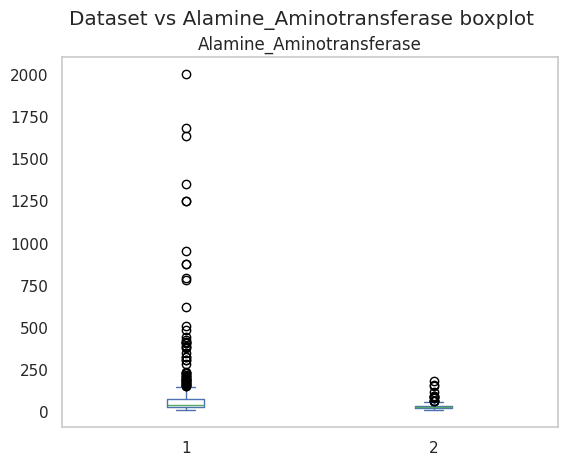

In [12]:
variable = "Alamine_Aminotransferase"

df.plot(
    kind="box",
    column=variable,
    by="Dataset",
    grid=False,
    title=f"Dataset vs Alamine_Aminotransferase boxplot",
);

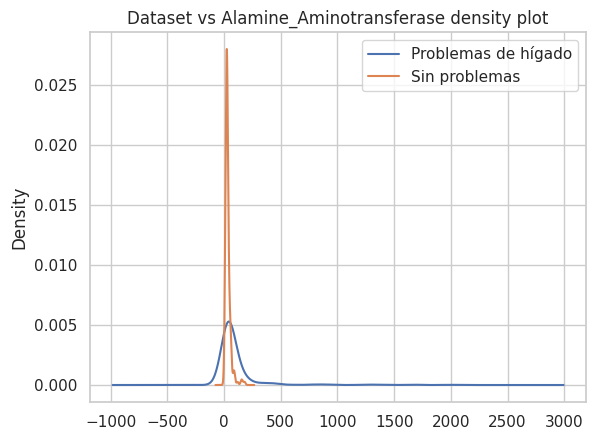

In [13]:
df[df["Dataset"] == "1"][variable].dropna().plot(
    kind="kde",
    label="Problemas de hígado",
    legend=True,
    title=f"Dataset vs Alamine_Aminotransferase density plot",
)
df[df["Dataset"] == "2"][variable].dropna().plot(
    kind="kde",
    label="Sin problemas",
    legend=True,
    xlabel=variable,
    ylabel="Densidad",
);

**Resultado:** ambas clases se concentran en valores bajos, pero la clase "problemas de hígado" tiene una cola derecha mucho más pesada (llega a 2000 mientras el máximo de la clase sana es 181).

**Interpretación:** valores bajos de ALT no distinguen las clases (muchos pacientes enfermos tienen ALT casi normal), pero valores altos son una señal fuerte de enfermedad. Es una variable que discrimina sobre todo en su cola derecha.

**Implicación:** muy útil en combinación con otras; además, esta asimetría sugiere que una transformación logarítmica podría ayudar a un futuro modelo a aprovecharla mejor.

##### Dataset vs Aspartate_Aminotransferase

**Pregunta concreta:** ¿la distribución de `Aspartate_Aminotransferase` es distinta entre pacientes con y sin problemas de hígado? Comparamos las dos clases con un boxplot agrupado y con las curvas de densidad de cada clase superpuestas, que muestran dónde se concentran los valores de cada grupo.

/tmp/ipykernel_71867/3433026734.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.plot(


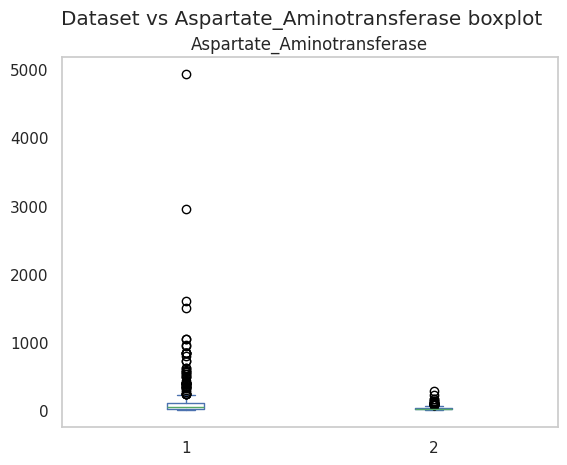

In [14]:
variable = "Aspartate_Aminotransferase"

df.plot(
    kind="box",
    column=variable,
    by="Dataset",
    grid=False,
    title=f"Dataset vs Aspartate_Aminotransferase boxplot",
);

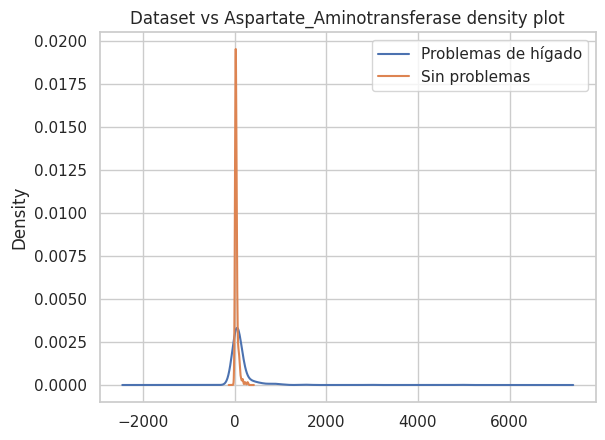

In [15]:
df[df["Dataset"] == "1"][variable].dropna().plot(
    kind="kde",
    label="Problemas de hígado",
    legend=True,
    title=f"Dataset vs Aspartate_Aminotransferase density plot",
)
df[df["Dataset"] == "2"][variable].dropna().plot(
    kind="kde",
    label="Sin problemas",
    legend=True,
    xlabel=variable,
    ylabel="Densidad",
);

**Resultado:** mismo comportamiento que ALT, con una cola derecha aún más extrema (hasta 4929 en la clase enferma).

**Interpretación e implicación:** como ALT, discrimina principalmente en valores altos. Dado que ALT y AST miden daño celular de forma relacionada, cabría esperar redundancia entre ambas; se verifica en la matriz de correlación.

##### Dataset vs Albumin

**Pregunta concreta:** ¿la distribución de `Albumin` es distinta entre pacientes con y sin problemas de hígado? Comparamos las dos clases con un boxplot agrupado y con las curvas de densidad de cada clase superpuestas, que muestran dónde se concentran los valores de cada grupo.

/tmp/ipykernel_71867/11852749.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.plot(


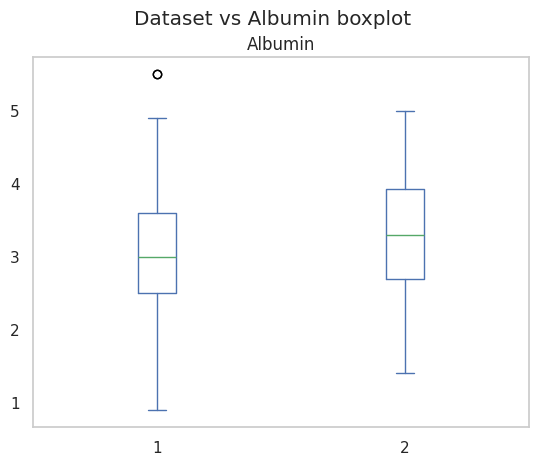

In [16]:
variable = "Albumin"

df.plot(
    kind="box",
    column=variable,
    by="Dataset",
    grid=False,
    title=f"Dataset vs Albumin boxplot",
);

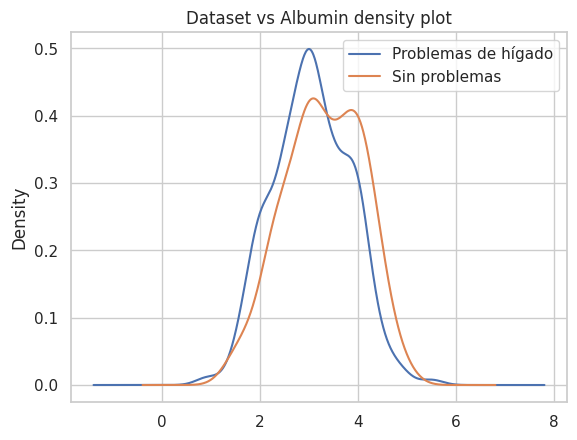

In [17]:
df[df["Dataset"] == "1"][variable].dropna().plot(
    kind="kde",
    label="Problemas de hígado",
    legend=True,
    title=f"Dataset vs Albumin density plot",
)
df[df["Dataset"] == "2"][variable].dropna().plot(
    kind="kde",
    label="Sin problemas",
    legend=True,
    xlabel=variable,
    ylabel="Densidad",
);

**Resultado:** la densidad de la clase "problemas de hígado" está desplazada hacia valores más bajos (pico cercano a 2.9) frente a la clase sana (pico cercano a 3.4).

**Interpretación:** a diferencia de las enzimas, la albúmina separa las clases en el centro de la distribución, no solo en la cola. Esto la hace especialmente valiosa: aporta información sobre pacientes con valores "medios", justo donde las enzimas no discriminan.

**Implicación:** junto con las bilirrubinas, es de las variables con señales más claras. Su tipo de señal (baja albúmina = enfermedad) es complementario al de las enzimas (valor alto = enfermedad).

#### Target vs variables categóricas

**Pregunta:** ¿la proporción de pacientes con problemas de hígado es distinta entre hombres y mujeres?

Para responderla calculamos el porcentaje de enfermedad de cada género (agrupando por género y promediendo el target numérico) y lo visualizamos con tablas de frecuencias cruzadas.

In [18]:
column = "Gender"

# porcentaje de pacientes con problemas de hígado por género
df.groupby(column, observed=True).agg({"target_num": "mean"}) * 100

,target_num
Gender,
Female,64.10
Male,73.57


**Resultado:** el 73.6% de los hombres tiene problemas de hígado, frente al 64.1% de las mujeres. Es una diferencia de unos 10 puntos porcentuales.

**Interpretación:** ambos géneros tienen mayorías de pacientes enfermos (coherente con el desbalance global de 71/29), pero la enfermedad es proporcionalmente algo más frecuente en los hombres de este dataset. Con los datos disponibles no podemos saber si esto refleja diferencias reales de prevalencia, diferencias en la derivación de pacientes o el azar del muestreo; además, las mujeres son solo el 24% de la muestra, así que su estimación tiene más incertidumbre.

**Implicación:** el género puede aportar una señal pequeña al futuro modelo, aunque parece secundaria frente a las pruebas clínicas. Veamos las cantidades absolutas.

In [19]:
tabla_genero = pd.crosstab(df["Gender"], df["Dataset"])
tabla_genero.columns = ["1 - problemas", "2 - sin problemas"]
tabla_genero

,1 - problemas,2 - sin problemas
Gender,,
Female,100,56
Male,359,129


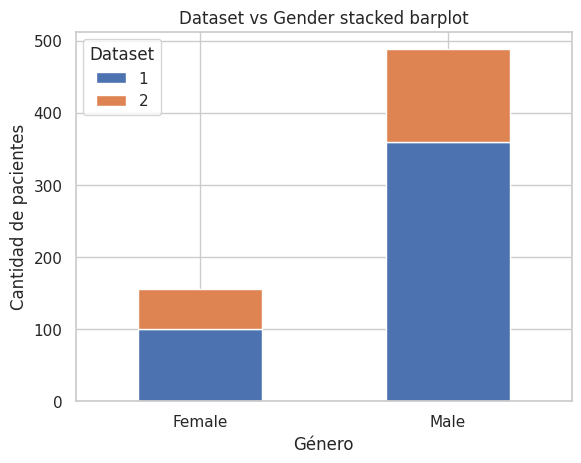

In [20]:
(
    pd.crosstab(df["Gender"], df["Dataset"]).plot(
        kind="bar", stacked=True, title="Dataset vs Gender stacked barplot"
    )
)
plt.xlabel("Género")
plt.ylabel("Cantidad de pacientes")
plt.xticks(rotation=0)
plt.show()

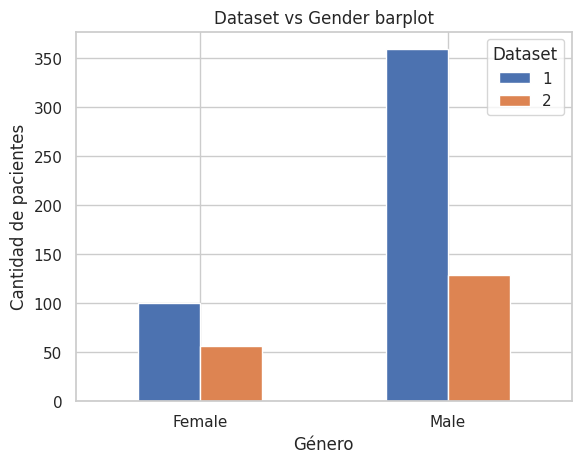

In [21]:
(
    pd.crosstab(df["Gender"], df["Dataset"]).plot(
        kind="bar",
        title="Dataset vs Gender barplot",
    )
)
plt.xlabel("Género")
plt.ylabel("Cantidad de pacientes")
plt.xticks(rotation=0)
plt.show()

**Interpretación de los gráficos:** en el gráfico apilado se ve que las mujeres, además de ser menos numerosas, tienen un segmento relativo mayor de pacientes sin problemas (naranja). En números absolutos: 359 hombres enfermos frente a 100 mujeres enfermas, y 129 hombres sanos frente a 56 mujeres sanas.

**Implicación para el proyecto:** la señal del género existe pero es débil. El riesgo más relevante no es la capacidad predictiva sino la representatividad: con pocas mujeres, las métricas del futuro modelo deberían revisarse por separado para cada género.

#### Variables numéricas vs variables numéricas

**Pregunta:** ¿qué tan relacionadas están las variables numéricas entre sí, y hay grupos que aporten información redundante?

Esto importa por dos motivos: la redundancia (multicolinealidad) puede dificultar la interpretación de algunos modelos y desperdiciar capacidad, y las relaciones fuertes también nos ayudan a entender la estructura clínica de los datos.

In [22]:
corr_matrix = df[numerical_columns].corr()
corr_matrix.round(2)

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
Age,1.00,0.00,-0.00,0.07,-0.09,-0.02,-0.16,-0.26,-0.22
Total_Bilirubin,0.00,1.00,0.89,0.21,0.19,0.23,0.01,-0.22,-0.21
Direct_Bilirubin,-0.00,0.89,1.00,0.23,0.21,0.25,0.02,-0.22,-0.20
Alkaline_Phosphotase,0.07,0.21,0.23,1.00,0.13,0.17,-0.01,-0.16,-0.23
Alamine_Aminotransferase,-0.09,0.19,0.21,0.13,1.00,0.78,-0.05,-0.02,0.02
Aspartate_Aminotransferase,-0.02,0.23,0.25,0.17,0.78,1.00,-0.03,-0.08,-0.05
Total_Protiens,-0.16,0.01,0.02,-0.01,-0.05,-0.03,1.00,0.77,0.21
Albumin,-0.26,-0.22,-0.22,-0.16,-0.02,-0.08,0.77,1.00,0.69
Albumin_and_Globulin_Ratio,-0.22,-0.21,-0.20,-0.23,0.02,-0.05,0.21,0.69,1.00


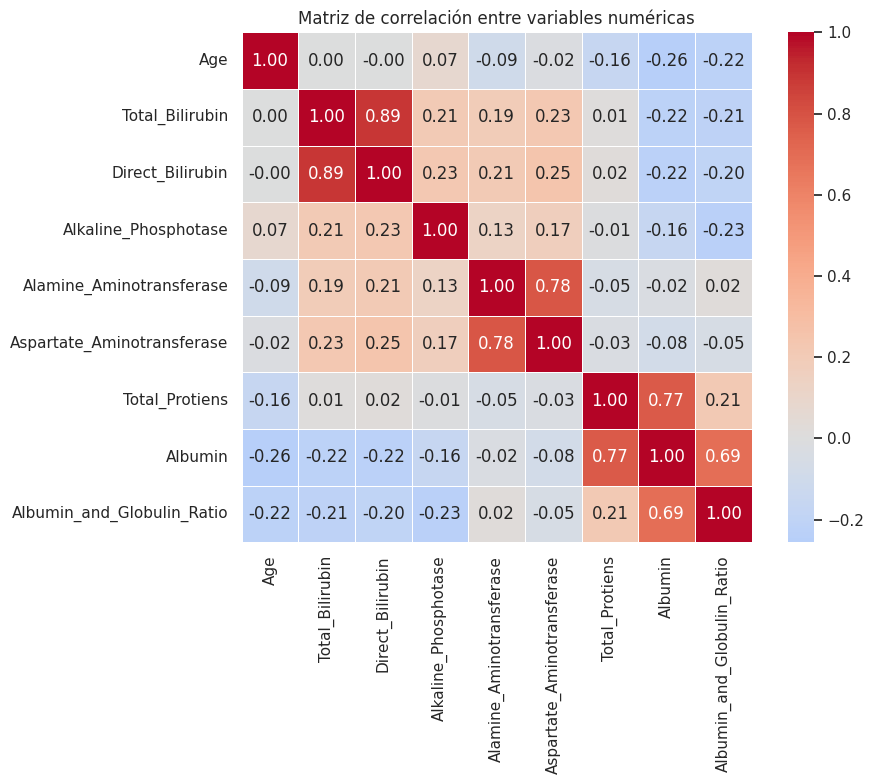

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

**Resultado:** las correlaciones más altas son:

- `Total_Bilirubin` y `Direct_Bilirubin`: **r = 0.89**.
- `Alamine_Aminotransferase` y `Aspartate_Aminotransferase`: **r = 0.78**.
- `Total_Protiens` y `Albumin`: **r = 0.77**.
- `Albumin` y `Albumin_and_Globulin_Ratio`: **r = 0.69**.

**Interpretación:** los pares con correlación alta tienen explicación clínica directa: la bilirrubina directa es una fracción de la total; ALT y AST se liberan juntas ante el daño celular; y la albúmina es un componente de las proteínas totales y el numerador del ratio A/G. Es decir, la redundancia viene de la propia construcción de las variables, no de un defecto de los datos.

**Implicación:** en la etapa de preparación de datos habrá que decidir si se conservan todas (los modelos basados en árboles toleran bien la multicolinealidad) o si se elimina una de cada par (más adecuado para modelos lineales e interpretación más simple). Importante: correlación no implica causalidad; estas relaciones reflejan cómo se miden las variables, no que una "cause" la otra.

Para ver la forma de estas relaciones, graficamos los cuatro pares más correlacionados, coloreando por clase del target.

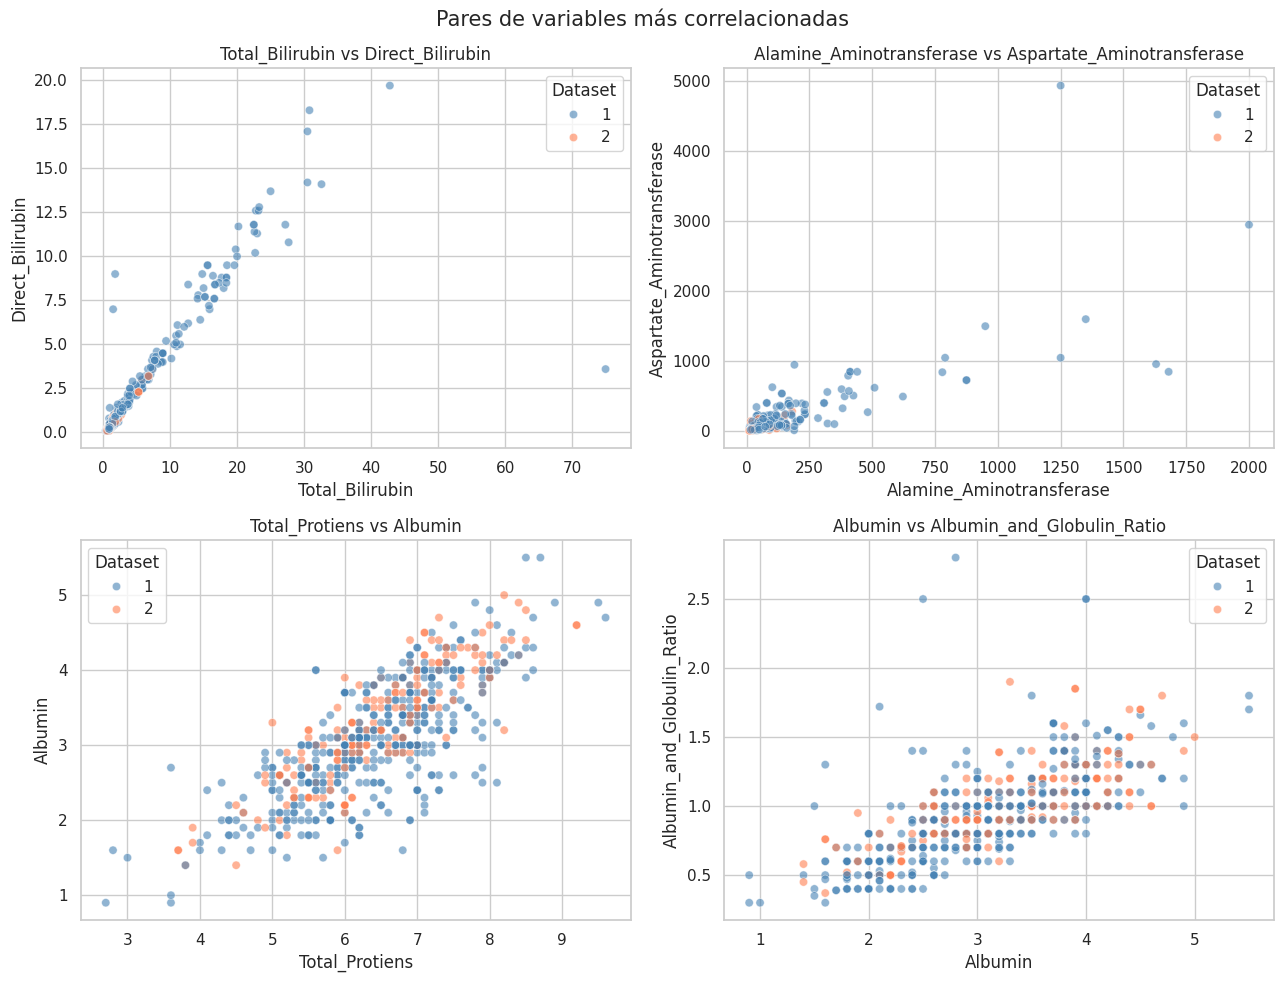

In [24]:
pares = [
    ("Total_Bilirubin", "Direct_Bilirubin"),
    ("Alamine_Aminotransferase", "Aspartate_Aminotransferase"),
    ("Total_Protiens", "Albumin"),
    ("Albumin", "Albumin_and_Globulin_Ratio"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for (x, y), ax in zip(pares, axes.flatten()):
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="Dataset",
        palette=["steelblue", "coral"],
        alpha=0.6,
        ax=ax,
    )
    ax.set_title(f"{x} vs {y}")
    ax.legend(title="Dataset")

plt.suptitle("Pares de variables más correlacionadas", fontsize=15)
plt.tight_layout()
plt.show()

**Qué observamos:** en los cuatro casos la relación es visible y aproximadamente lineal-creciente. En el gráfico de bilirrubinas se aprecia además que los pacientes sanos (coral) se concentran en la esquina inferior izquierda (ambas bilirrubinas bajas) y que la nube de enfermos (azul) se abre hacia arriba y a la derecha.

**Interpretación:** los pacientes sanos forman un grupo compacto con pruebas en rango bajo; los enfermos se dispersan hacia valores altos. Esto es una buena noticia para un futuro clasificador: los sanos son relativamente fáciles de caracterizar; la dificultad estará en los enfermos con valores cercanos a lo normal.

##### Correlación de cada variable con el target

**Pregunta:** ordenadas por su relación lineal con el diagnóstico, ¿qué variables encabezan la lista? Esto da un primer ranking de variables candidatas para el modelo. Usamos el target numérico auxiliar (1 = problemas de hígado).

In [ ]:
corr_target = (
    df[numerical_columns + ["target_num"]].corr()["target_num"].drop("target_num")
)
corr_target = corr_target.sort_values(ascending=False)

print("Correlación de cada variable numérica con el target (3 decimales):")
print("(target_num = 1 si el paciente tiene problemas de hígado)")
print(corr_target.map(lambda x: f"{x:.3f}").to_string())

Correlación de cada variable numérica con el target (3 decimales):
(target_num = 1 si el paciente tiene problemas de hígado)
Direct_Bilirubin               0.246
Total_Bilirubin                0.219
Alkaline_Phosphotase           0.179
Alamine_Aminotransferase       0.165
Aspartate_Aminotransferase     0.156
Age                            0.128
Total_Protiens                -0.025
Albumin_and_Globulin_Ratio    -0.139
Albumin                       -0.141


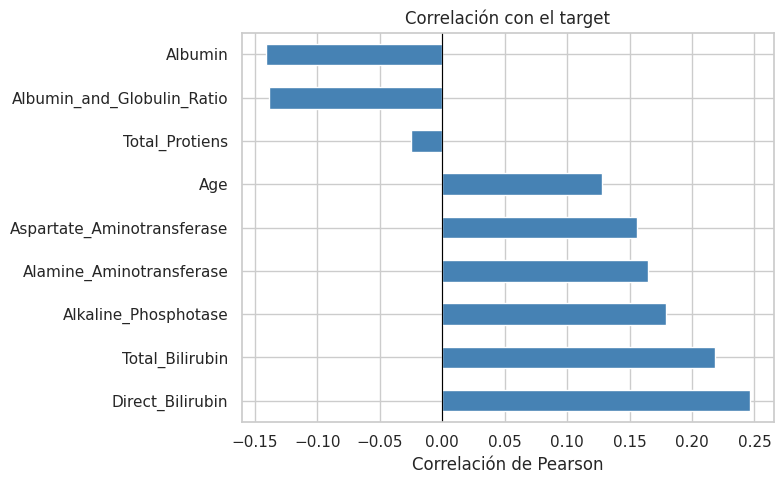

In [26]:
corr_target.plot(
    kind="barh", color="steelblue", figsize=(8, 5), title="Correlación con el target"
)
plt.xlabel("Correlación de Pearson")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

**Resultado:** las correlaciones positivas más altas son `Direct_Bilirubin` (0.25) y `Total_Bilirubin` (0.22), seguidas de `Alkaline_Phosphotase` (0.18), `Alamine_Aminotransferase` (0.165), `Aspartate_Aminotransferase` (0.156) y `Age` (0.13). En negativa: `Albumin` (-0.14) y `Albumin_and_Globulin_Ratio` (-0.14). `Total_Protiens` prácticamente no correlaciona (-0.03).

**Interpretación:** ninguna correlación lineal es alta en valor absoluto. Esto no significa que las variables no sirvan: la correlación de Pearson solo mide relaciones lineales, y en variables tan asimétricas la señal puede estar en la cola (como vimos con ALT y AST) o en combinaciones de variables. El ranking coincide además con lo que vimos en los boxplots y en las medianas por clase, lo que da confianza en la conclusión.

**Implicación:** un futuro modelo necesitará combinar varias variables, y posiblemente capturar relaciones no lineales, para separar bien las clases. No hay una única variable "resolutiva".

#### Variables categóricas vs variables numéricas

**Pregunta:** ¿el género se relaciona con los valores de las pruebas clínicas?

Esta pregunta importa porque, si los hombres y las mujeres del dataset difieren sistemáticamente en sus pruebas, parte de la señal del género que vimos antes podría en realidad ser un reflejo de esas diferencias clínicas (o al revés).

In [27]:
# medianas de las pruebas clínicas por género
medianas_genero = df.groupby("Gender", observed=True)[numerical_columns].median().T
medianas_genero.columns = ["Female", "Male"]
medianas_genero

,Female,Male
Age,44.50,46.00
Total_Bilirubin,0.80,1.30
Direct_Bilirubin,0.20,0.50
Alkaline_Phosphotase,192.00,215.00
Alamine_Aminotransferase,25.00,38.00
Aspartate_Aminotransferase,29.00,48.00
Total_Protiens,6.70,6.40
Albumin,3.25,3.00
Albumin_and_Globulin_Ratio,0.91,0.95


**Resultado:** los hombres tienen medianas más altas en todas las pruebas de daño hepático: bilirrubina total (1.3 vs 0.8), bilirrubina directa (0.5 vs 0.2), fosfatasa alcalina (215 vs 192), ALT (38 vs 25) y AST (48 vs 29). Las mujeres tienen más proteínas totales (6.7 vs 6.4) y albúmina (3.25 vs 3.0).

**Interpretación:** los hombres de este dataset están, en promedio, "peores" en las pruebas hepáticas, lo que es coherente con que también tengan mayor proporción de diagnóstico positivo (73.6% vs 64.1%). Visualizamos las tres enzimas para confirmar el patrón.

/tmp/ipykernel_71867/4142963214.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gender", y=col, ax=ax, palette=["salmon", "steelblue"])
/tmp/ipykernel_71867/4142963214.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gender", y=col, ax=ax, palette=["salmon", "steelblue"])
/tmp/ipykernel_71867/4142963214.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gender", y=col, ax=ax, palette=["salmon", "steelblue"])


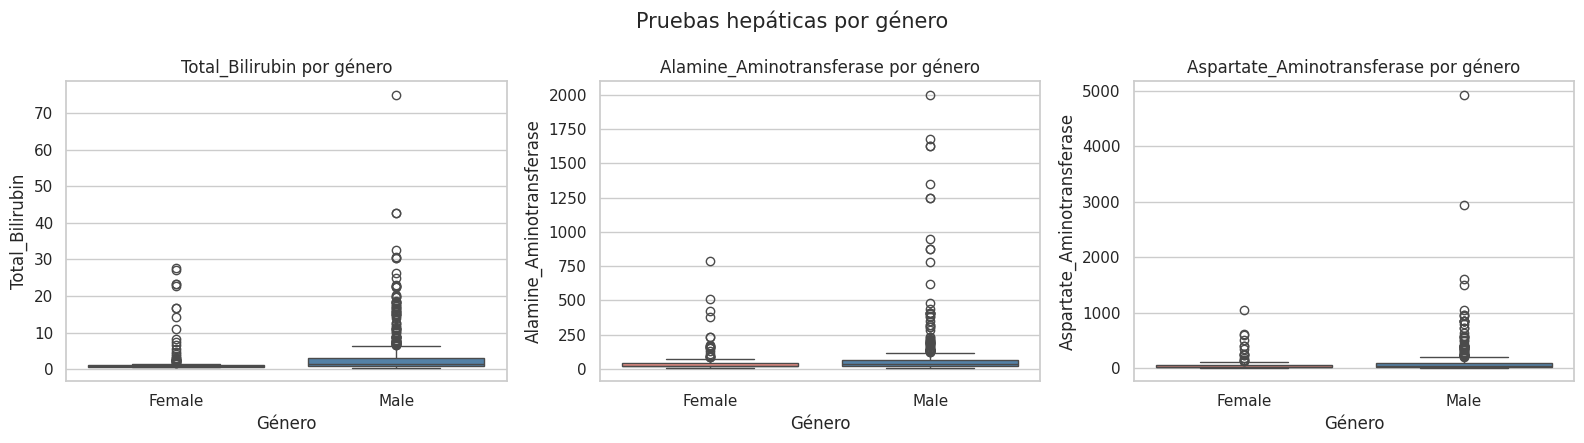

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(
    axes, ["Total_Bilirubin", "Alamine_Aminotransferase", "Aspartate_Aminotransferase"]
):
    sns.boxplot(data=df, x="Gender", y=col, ax=ax, palette=["salmon", "steelblue"])
    ax.set_title(f"{col} por género")
    ax.set_xlabel("Género")

plt.suptitle("Pruebas hepáticas por género", fontsize=15)
plt.tight_layout()
plt.show()

**Qué observamos:** los boxplots confirman las medianas: las cajas de los hombres están desplazadas hacia arriba en las tres pruebas, aunque con mucha superposición entre géneros.

**Interpretación:** el género no es una variable "independiente" del resto: se asocia con niveles distintos de las pruebas. Para el futuro modelo esto sugiere que el género podría aportar poca información *adicional* una vez incluidas las pruebas clínicas, aunque no puede descartarse alguna interacción.

**Implicación:** vale la pena explorar en el análisis multivariable (notebook 04) si el patrón de las pruebas frente al diagnóstico es distinto en hombres y mujeres.

#### Comprobación estadística de las diferencias observadas

Hasta aquí las comparaciones entre clases fueron visuales (boxplots, densidades, medianas). Para no depender solo de la impresión gráfica, las confirmamos con dos pruebas estadísticas estándar:

- **Mann-Whitney U** para cada variable numérica: comprueba si las distribuciones de la clase `1` y la clase `2` difieren de forma significativa. La elegimos en lugar de la t de Student porque las pruebas hepáticas están muy sesgadas y esta prueba no exige normalidad.
- **Chi-cuadrado** para la relación entre `Gender` y `Dataset`: comprueba si la proporción de enfermedad difiere entre géneros más de lo esperable por azar.

Un p-valor pequeño (menor a 0.05, ajustado por comparaciones múltiples) indica que la diferencia observada difícilmente se debe al azar. Ojo: la significancia estadística no mide el tamaño del efecto; con 648 pacientes etiquetados, diferencias moderadas pueden ser significativas.

In [29]:
from scipy import stats

# Mann-Whitney U por variable numerica (clase 1 vs clase 2)
d_etiq = df.dropna(subset=["Dataset"])

resultados = []
for col in numerical_columns:
    g1 = d_etiq[d_etiq["Dataset"] == "1"][col].dropna()
    g2 = d_etiq[d_etiq["Dataset"] == "2"][col].dropna()
    u, p_valor = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    resultados.append({"variable": col, "p_valor": p_valor})

tabla_mwu = pd.DataFrame(resultados).set_index("variable")
tabla_mwu["significativa (p < 0.05/9)"] = tabla_mwu["p_valor"] < 0.05 / 9
# formateamos el p-valor con 6 decimales para no perder precision en pantalla
tabla_mwu["p_valor"] = tabla_mwu["p_valor"].map(lambda x: f"{x:.6f}")
tabla_mwu

,p_valor,significativa (p < 0.05/9)
variable,,
Age,0.001608,True
Total_Bilirubin,0.000000,True
Direct_Bilirubin,0.000000,True
Alkaline_Phosphotase,0.000000,True
Alamine_Aminotransferase,0.000000,True
Aspartate_Aminotransferase,0.000000,True
Total_Protiens,0.647280,False
Albumin,0.000289,True
Albumin_and_Globulin_Ratio,0.000028,True


In [ ]:
# chi-cuadrado de Genero vs Dataset
tabla_contingencia = pd.crosstab(df["Gender"], df["Dataset"])
chi2, p_valor_chi2, dof, _ = stats.chi2_contingency(tabla_contingencia)

print(
    f"Chi-cuadrado Gender vs Dataset: chi2 = {chi2:.2f}, grados de libertad = {dof}, p-valor = {p_valor_chi2:.4f}"
)

Chi-cuadrado Gender vs Dataset: chi2 = 4.72, grados de libertad = 1, p-valor = 0.0298


: 

**Resultado de Mann-Whitney:** ocho de las nueve variables numéricas presentan diferencias altamente significativas entre clases (p < 0.001, por debajo incluso del umbral corregido por comparaciones múltiples de 0.05/9 ≈ 0.0056): las dos bilirrubinas, la fosfatasa alcalina, las dos transaminasas, la albúmina y el ratio A/G (y también la edad, con p = 0.0016). La única excepción es `Total_Protiens`, con p = 0.647: sus distribuciones son estadísticamente indistinguibles entre enfermos y sanos, lo que confirma lo que ya sugerían las medianas idénticas (6.5 y 6.5).

**Resultado del chi-cuadrado:** la asociación entre género y diagnóstico es significativa al nivel habitual (chi² = 4.72, p = 0.0298), aunque justo en el límite: con la muestra de mujeres disponible (156), la evidencia es modesta y no permitiría descartar del todo el azar si aplicáramos criterios más estrictos.

**Interpretación:** las señales visuales del análisis bivariable no eran ilusiones: prácticamente todas las variables clínicas difieren de forma sistemática entre clases. La edad, que en los gráficos parecía poco informativa, sí presenta una diferencia significativa (los enfermos son mayores en promedio), aunque con una correlación débil. En el extremo opuesto, `Total_Protiens` queda estadísticamente descartada como discriminador por sí sola.

**Implicación para el proyecto:** estas pruebas respaldan mantener como predictoras a todas las variables excepto, posiblemente, `Total_Protiens` (aunque podría aportar en combinación con otras, así que la decisión de descartarla corresponde a la etapa de modelado). La señal del género es real pero débil y con evidencia limitada.

### Conclusiones del análisis bivariable

**¿Qué relaciones encontramos?**

- **Target vs numéricas:** las clases se separan de forma visible en las bilirrubinas, la fosfatasa alcalina, las transaminasas (los enfermos tienen valores más altos) y en la albúmina y el ratio A/G (los enfermos tienen valores más bajos). La edad también diferencia (medianas de 46 vs 39 años, p = 0.0016 en Mann-Whitney) y las proteínas totales no distinguen (p = 0.65). Ninguna variable separa las clases por sí sola.
- **Ranking por correlación lineal con el target:** Direct_Bilirubin (0.25), Total_Bilirubin (0.22), Alkaline_Phosphotase (0.18), ALT (0.165), AST (0.156), Age (0.13) en positivo; Albumin (-0.14) y ratio A/G (-0.14) en negativo.
- **Target vs género:** 73.6% de enfermedad en hombres vs 64.1% en mujeres: señal real pero débil (chi-cuadrado p = 0.030), y con la cautela de que las mujeres son solo el 24% de la muestra.
- **Redundancia:** correlaciones altas entre Total_Bilirubin y Direct_Bilirubin (0.89), ALT y AST (0.78), Total_Protiens y Albumin (0.77), Albumin y ratio A/G (0.69). La redundancia proviene de la propia definición clínica de las variables y deberá resolverse (o tolerarse) en la etapa de preparación.
- **Género vs pruebas:** los hombres presentan pruebas hepáticas más alteradas que las mujeres, lo que contextualiza la diferencia de diagnóstico entre géneros.

**Conclusión general del bloque:** existen señales claras y clínicamente coherentes para predecir el diagnóstico, pero ninguna variable es suficiente por sí sola: el futuro modelo tendrá que combinar varias. Queda por explorar si combinaciones de variables (análisis multivariable) revelan patrones adicionales: ese es el objeto del notebook 04.

## 📊 Análisis de resultados y conclusiones

El análisis bivariable confirma que el dataset contiene información útil para predecir el diagnóstico: las pruebas hepáticas difieren entre clases de forma sistemática y en la dirección que espera la clínica. Las bilirrubinas y la albúmina son las variables con señal más clara, y el género aporta una señal menor que parece mediada por las diferencias en las pruebas. La correlación entre variables relacionadas clínicamente (0.89 entre las bilirrubinas) es el principal problema estructural detectado.

## 💡 Propuestas e ideas

- Explorar interacciones de tres variables (target + género + prueba, target + edad + prueba) en el notebook 04.
- En la etapa de preparación de datos: decidir el tratamiento de la redundancia (por ejemplo, conservar solo una bilirrubina en modelos lineales).
- Considerar la transformación logarítmica de las pruebas hepáticas para que las relaciones lineales (y las correlaciones) se aproximen mejor al patrón real.
- Evaluar métricas por género cuando exista el modelo, dada la baja representación de mujeres.

## 📖 Referencias

- Guía breve de análisis bivariable en Python: <https://www.analyticsvidhya.com/blog/2022/02/a-quick-guide-to-bivariate-analysis-in-python/>
- Pruebas estadísticas comunes en ciencia de datos: <https://nathanrosidi.medium.com/commonly-used-statistical-tests-in-data-science-93787568eb36>
- Documentación de seaborn: <https://seaborn.pydata.org/>